In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'src'))

from fetch_trivsel_fravaer import fetch, QUERY_FRAVAER, QUERY_TRIVSEL, QUERY_FORAELDRE
from validate import valider_data, kommune_antal, sammenlign_kommuner_for_dataframes

import json
import requests
import pandas as pd
from pathlib import Path

In [21]:
df_trivsel = fetch(QUERY_TRIVSEL, "Trivsel")
df_fravaer = fetch(QUERY_FRAVAER, "Fravær")
df_foraeldre = fetch(QUERY_FORAELDRE, "Forældres uddannelse")

Trivsel: hentede 777 rækker
Fravær: hentede 384 rækker
Forældres uddannelse: hentede 2273 rækker


In [22]:
display(df_trivsel.head())
display(df_fravaer.head())
display(df_foraeldre.head())

,[Institution].[Beliggenhedskommune].[Beliggenhedskommune],[Klassetrin].[Klassetringruppe].[Klassetringruppe],[Skoleår].[Skoleår].[Skoleår],[Trivselsindikator].[Trivselsindikator].[Trivselsindikator],[Trivselsindikator Svarintervaller].[Trivselsindikator Svarintervaller].[Trivselsindikator Svarintervaller],Andel Indikatorsvar
0,Albertslund,Udskoling,2024/2025,Generel trivsel,"4,1 til 5","14,4 %"
1,Albertslund,Udskoling,2024/2025,Generel trivsel,"3,1 til 4","68,0 %"
2,Albertslund,Udskoling,2024/2025,Generel trivsel,"2,1 til 3","16,9 %"
3,Albertslund,Udskoling,2024/2025,Generel trivsel,1 til 2,"0,7 %"
4,Albertslund,Mellemtrin,2024/2025,Generel trivsel,"4,1 til 5","23,7 %"


,[Institution].[Beliggenhedskommune].[Beliggenhedskommune],[Klassetrin].[Skoletrin].[Skoletrin],[Tid].[Skoleår].[Skoleår],Gennemsnitligt fravær per skoleår
0,Albertslund,10. klasse mv.,2024/2025,"16,7 %"
1,Albertslund,Indskoling,2024/2025,"6,9 %"
2,Albertslund,Mellemtrin,2024/2025,"7,8 %"
3,Albertslund,Udskoling,2024/2025,"8,2 %"
4,Allerød,Indskoling,2024/2025,"6,4 %"


,[Forældres Højest Fuldførte Uddannelse].[Uddannelsesgruppe].[Uddannelsesgruppe],[Institution].[Beliggenhedskommune].[Beliggenhedskommune],[Klassetrin].[Klassetringruppe].[Klassetringruppe],[Skoleår].[Skoleår].[Skoleår],Antal elever
0,<fejl>,Esbjerg,Mellemtrin,2024/2025,5
1,<fejl>,Fredericia,Indskoling,2024/2025,6
2,<fejl>,Gladsaxe,Mellemtrin,2024/2025,5
3,<fejl>,Herning,Indskoling,2024/2025,9
4,<fejl>,Horsens,Indskoling,2024/2025,5


## Validering og rensning af data

In [23]:
#Check kollonnenavne

df_fravaer.columns

df_trivsel.columns

Index(['[Institution].[Beliggenhedskommune].[Beliggenhedskommune]',
       '[Klassetrin].[Klassetringruppe].[Klassetringruppe]',
       '[Skoleår].[Skoleår].[Skoleår]',
       '[Trivselsindikator].[Trivselsindikator].[Trivselsindikator]',
       '[Trivselsindikator Svarintervaller].[Trivselsindikator Svarintervaller].[Trivselsindikator Svarintervaller]',
       'Andel Indikatorsvar'],
      dtype='str')

In [24]:
#Omdøb kolonnerne til mere læsevenlige navne
df_trivsel = df_trivsel.rename(columns={
    '[Institution].[Beliggenhedskommune].[Beliggenhedskommune]': 'kommune',
    '[Klassetrin].[Klassetringruppe].[Klassetringruppe]': 'klassetrin',
    '[Skoleår].[Skoleår].[Skoleår]': 'skoleår',
    '[Trivselsindikator].[Trivselsindikator].[Trivselsindikator]': 'trivselsindikator',
    '[Trivselsindikator Svarintervaller].[Trivselsindikator Svarintervaller].[Trivselsindikator Svarintervaller]': 'svarinterval',
    'Andel Indikatorsvar': 'andel',
    '[Forældres Højest Fuldførte Uddannelse].[Uddannelsesgruppe].[Uddannelsesgruppe]': 'højeste_uddannelse'
})

df_fravaer = df_fravaer.rename(columns={
    '[Institution].[Beliggenhedskommune].[Beliggenhedskommune]': 'kommune',
    '[Klassetrin].[Skoletrin].[Skoletrin]': 'klassetrin',
    '[Tid].[Skoleår].[Skoleår]': 'skoleår',
    'Gennemsnitligt fravær per skoleår': 'fravaer',
    '[Forældres Højest Fuldførte Uddannelse].[Uddannelsesgruppe].[Uddannelsesgruppe]': 'højeste_uddannelse'
})

df_foraeldre = df_foraeldre.rename(columns={
    '[Forældres Højest Fuldførte Uddannelse].[Uddannelsesgruppe].[Uddannelsesgruppe]': 'uddannelsesgruppe',
    '[Institution].[Beliggenhedskommune].[Beliggenhedskommune]': 'kommune',
    '[Klassetrin].[Klassetringruppe].[Klassetringruppe]': 'klassetrin',
    '[Skoleår].[Skoleår].[Skoleår]': 'skoleår',
    'Antal elever': 'antal_elever'
})

#Vi slår kategorierne med fejl og uoplyst uddannelsesniveau sammen, da det her ikke har betydning hvilken der er tale om. 
df_foraeldre['uddannelsesgruppe'] = df_foraeldre['uddannelsesgruppe'].replace('<fejl>', '<uoplyst>')


Da der i elevantallet er brugt punktum som tusind-separator skal disse fjernes for at sikre korrekt konvertering til heltal. Derefter tjekker vi at det totale elevantal er i den korrekte størrelsesorden. I skoleåret 2024/2025 var der cirka 673.000 grundskoleelever.  

In [25]:

df_foraeldre['antal_elever'] = (df_foraeldre['antal_elever'].astype(str)
                                  .str.replace('.', '', regex=False)
                                  .astype(int))

df_foraeldre['antal_elever'].sum()


np.int64(449226)

Antallet af elever i data er cirka 450000, hvilket er i den korrekte størrelsesorden og mindre end det totale elevantal. Da vi ikke har medtaget elever der har valgt "ønsker ikke at svare" på forældres uddannelsesniveau, forventes der ikke at være data fra alle skoleelever. 

Vi benytter valideringsfunktionen defineret i src til at tjekke at der er det korrekte antal unikke kommuner og at fraværsprocent og trivselsscore ligger i det korrekte interval (0-100)

In [26]:
valider_data(df_trivsel, "Trivsel")
valider_data(df_fravaer, "Fravær")
valider_data(df_foraeldre, "Forældre")

--- Trivsel ---
Rækker: 777, Kommuner: 99
Manglende værdier:
Series([], dtype: int64)
Alle tjek bestået.

--- Fravær ---
Rækker: 384, Kommuner: 98
Manglende værdier:
Series([], dtype: int64)
Alle tjek bestået.

--- Forældre ---
Rækker: 2273, Kommuner: 98
Manglende værdier:
Series([], dtype: int64)
Alle tjek bestået.



In [27]:
sammenlign_kommuner_for_dataframes({
    'trivsel': df_trivsel,
    'fravaer': df_fravaer,
    'forældre': df_foraeldre
})

Kommuner i alt (union): 99
Kommuner fælles for alle datasæt: 98

⚠️  1 kommune(r) findes ikke i alle datasæt:
  - Christiansø: findes i ['trivsel'], mangler i ['fravaer', 'forældre']


{'Christiansø'}

Trivselsdata inkluderer Christiansø mens de andre datasæt ikke gør, vi udelader den derfor i den videre analyse hvor den vil bortfalde når vi laver indre joins over kommuner.

In [28]:
#Tjek hvilke klassetrin der er repræsenteret

display(df_trivsel['klassetrin'].unique())
display(df_fravaer['klassetrin'].unique())
display(df_foraeldre['klassetrin'].unique())

<StringArray>
['Udskoling', 'Mellemtrin']
Length: 2, dtype: str

<StringArray>
['10. klasse mv.', 'Indskoling', 'Mellemtrin', 'Udskoling']
Length: 4, dtype: str

<StringArray>
['Mellemtrin', 'Indskoling', 'Udskoling']
Length: 3, dtype: str

Vær opmærksom på at de tre datasæt ikke indeholder de samme kategorier for klassetrin. Vi kommer til at fokusere på dem de har til fælles, hvilket er mellemtrin og udskoling. 

Til den videre databehandling konverterer vi dataen for andel i svarintervaller og fraværsprocent fra tekst til floats.

In [29]:
#Definer en funktion som konverterer strenge med procentdata til float.

def to_float(series):
    return (series.astype(str)
                  .str.replace('%', '', regex=False)
                  .str.replace(',', '.', regex=False)
                  .str.strip()
                  .astype(float))

Nu genereres den samlede dataframe som dækker både fravær og trivsel. 

In [30]:
merged_df = df_trivsel.merge(df_fravaer, on=['kommune', 'klassetrin', 'skoleår'], how='inner')

#Andel og fravær er tekststrenge som her konverteres til float
merged_df['andel_pct'] = to_float(merged_df['andel'])
merged_df['fravaer_pct'] = to_float(merged_df['fravaer'])

#Slet de andre kolonner med fravær og andel
merged_df = merged_df.drop(columns=["andel","fravaer"])

merged_df.head()

,kommune,klassetrin,skoleår,trivselsindikator,svarinterval,andel_pct,fravaer_pct
0,Albertslund,Udskoling,2024/2025,Generel trivsel,"4,1 til 5",14.4,8.2
1,Albertslund,Udskoling,2024/2025,Generel trivsel,"3,1 til 4",68.0,8.2
2,Albertslund,Udskoling,2024/2025,Generel trivsel,"2,1 til 3",16.9,8.2
3,Albertslund,Udskoling,2024/2025,Generel trivsel,1 til 2,0.7,8.2
4,Albertslund,Mellemtrin,2024/2025,Generel trivsel,"4,1 til 5",23.7,7.8


svarinterval   1 til 2  2,1 til 3  3,1 til 4  4,1 til 5
klassetrin                                             
Mellemtrin    0.608602  11.723469  62.493878  25.195918
Udskoling     0.882979  14.265306  68.938776  15.944898


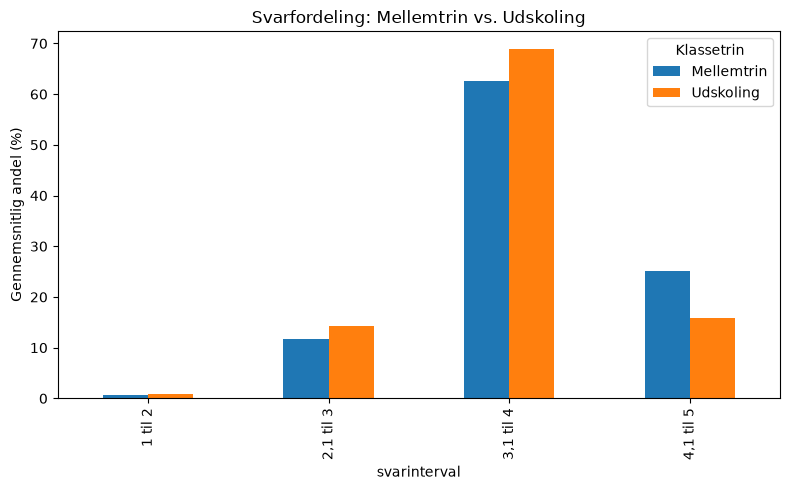

In [31]:
import matplotlib.pyplot as plt

fordeling = merged_df.groupby(['klassetrin', 'svarinterval'])['andel_pct'].mean().unstack()
fordeling = fordeling[['1 til 2', '2,1 til 3', '3,1 til 4', '4,1 til 5']]  # order them logically
print(fordeling)

fordeling.T.plot(kind='bar', figsize=(8, 5))
plt.ylabel('Gennemsnitlig andel (%)')
plt.title('Svarfordeling: Mellemtrin vs. Udskoling')
plt.legend(title='Klassetrin')
plt.tight_layout()
plt.show()

I analysen af disse data ønsker vi at undersøge korrelationen mellem fravær og trivsel i skolen. Her er det ikke umiddelbart muligt at lave en regression med den nuværende opgivelse i svarintervaller. Vi definerer derfor en trivsels_score som udregnes som et vægtet gennemsnit baseret på den miderste værdi i intervallerne. 
Den vægtede trivsels-score antager, at besvarelser inden for hvert svarinterval er jævnt fordelt omkring intervallets midtpunkt. Denne antagelse kan ikke verificeres ud fra de tilgængelige data, da vi kun har adgang til andelen i hvert interval, ikke de individuelle besvarelser. Hvis fordelingen inden for intervallerne er skæv, kan den beregnede trivsels-score være en upræcis approksimation af den faktiske gennemsnitlige trivsel.

I første omgang forsøgtes analysen gennemført med en trivselsscore som var definere som andel af svar i øverste svarinterval, men dette viste sig at være for en for grov forsimpling idet tilgængelig information om hele fordelingen af svar ikke blev inkluderet. Det giver tendens til at overestimere mistrivsel, idet en elev kan have svaret f.eks. 3,9, hvilket med den simple trivselsscore slet ikke bidrager til den gennemsnitlige trivselsscore fordi det er under det kunstige cutoff ved 4. Denne analyse er derfor ikke medtaget here, og vi bruger the vægtede gennemsnit som et stadig simpelt, men dog mere detaljeret, mål for trivslen.


In [32]:
midpoints = {
    '1 til 2': 1.5,
    '2,1 til 3': 2.55,
    '3,1 til 4': 3.55,
    '4,1 til 5': 4.55
}

merged_df['midpoint'] = merged_df['svarinterval'].map(midpoints)
merged_df['weighted'] = merged_df['andel_pct'] * merged_df['midpoint']

trivsel_score = (merged_df.groupby(['kommune', 'klassetrin', 'skoleår', 'fravaer_pct'])
                    .apply(lambda g: g['weighted'].sum() / g['andel_pct'].sum())
                    .reset_index(name='trivsel_score'))

trivsel_score.head()

,kommune,klassetrin,skoleår,fravaer_pct,trivsel_score
0,Aabenraa,Mellemtrin,2024/2025,6.6,3.667768
1,Aabenraa,Udskoling,2024/2025,7.7,3.524200
2,Aalborg,Mellemtrin,2024/2025,8.9,3.718750
3,Aalborg,Udskoling,2024/2025,9.9,3.573500
4,Aarhus,Mellemtrin,2024/2025,6.4,3.733033


In [33]:
#Tjek at datatyperne er korrekte

trivsel_score.dtypes

kommune              str
klassetrin           str
skoleår              str
fravaer_pct      float64
trivsel_score    float64
dtype: object

For at tildele en gennemsnitlig uddannelsesscore bruger vi skalaen for uddannelsesniveau fra den danske kvalifikationsramme

In [34]:
uddannelsesniveau = {
    '0.-9. klasse': 2,
    '10. klasse mv': 3,
    'Erhvervsuddannelse': 4,
    'Gymnasial uddannelse': 4,
    'Korte videregående uddannelser': 5,
    'Mellemlange videregående uddannelser': 6,
    'Lange videregående uddannelser': 7,
    '<uoplyst>': None  # excluded from weighted average
}

df_foraeldre['niveau'] = df_foraeldre['uddannelsesgruppe'].map(uddannelsesniveau)

Udregn uddannelsesscore for hver kommune som et vægtet gennemsnit

In [37]:
uoplyst_share = df_foraeldre[df_foraeldre['uddannelsesgruppe'] == '<uoplyst>'].groupby('kommune')['antal_elever'].sum() / df_foraeldre.groupby('kommune')['antal_elever'].sum()
uoplyst_share.describe()

count    89.000000
mean      0.010772
std       0.005394
min       0.002753
25%       0.006882
50%       0.009775
75%       0.013565
max       0.030669
Name: antal_elever, dtype: float64

En kontrol af andelen af elever med 'uoplyst' uddannelsesniveau viser, at denne er lav og forholdsvis ensartet på tværs af kommuner (gennemsnit ca. 1,1 %, maksimalt ca. 3,1 %), hvorfor denne begrænsning vurderes at have minimal praktisk betydning for sammenligningen af uddannelsesscoren mellem kommuner, og vi udelader de datarækker som har manglende uddannelsesniveau i den følgende analyse. 

In [35]:
kendt = df_foraeldre.dropna(subset=['niveau']).copy()
kendt['weighted'] = kendt['antal_elever'] * kendt['niveau']

uddannelse_score = (kendt.groupby(['kommune', 'klassetrin'])
                    .apply(lambda g: g['weighted'].sum() / g['antal_elever'].sum())
                    .reset_index(name='foraeldre_uddannelsesniveau'))

uddannelse_score.head()

,kommune,klassetrin,foraeldre_uddannelsesniveau
0,Aabenraa,Indskoling,4.940664
1,Aabenraa,Mellemtrin,4.837537
2,Aabenraa,Udskoling,4.880469
3,Aalborg,Indskoling,5.571569
4,Aalborg,Mellemtrin,5.503681


In [36]:
#Eksportér den rensede data til csv-fil
trivsel_score.to_csv("../data/processed/trivsel_fravaer_merged.csv", index=False)
uddannelse_score.to_csv("../data/processed/uddannelse_score.csv", index=False)